In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
#Data Wrangling II 
#Create an “Academic performance” dataset of students and perform the following operations using Python. 
#1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use any of the suitable techniques to deal with them.   
#2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with them.  
#3. Apply data transformations on at least one of the variables. The purpose of this transformation should be one of the following reasons: to change the scale for better 
# understanding of the variable, to convert a non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal distribution. 

In [82]:
#create academic dataset
data=   {
       'Name':['A','B','C','D','E'],
       'Math':[48,88,np.nan,90,187],
       'Sci':[58,89,np.nan,96,207],
       'Eng':[98,78,np.nan,91,68]
        }
df=pd.DataFrame(data)
print(data)
df

{'Name': ['A', 'B', 'C', 'D', 'E'], 'Math': [48, 88, nan, 90, 187], 'Sci': [58, 89, nan, 96, 207], 'Eng': [98, 78, nan, 91, 68]}


,Name,Math,Sci,Eng
0,A,48.0,58.0,98.0
1,B,88.0,89.0,78.0
2,C,NaN,NaN,NaN
3,D,90.0,96.0,91.0
4,E,187.0,207.0,68.0


In [83]:
# 1. Scan all variables for missing values and inconsistencies.
# missing values
df['Math'].fillna(df['Math'].mean() , inplace=True)
df['Sci'].fillna(df['Sci'].mean() , inplace=True)
df['Eng'].fillna(df['Eng'].mean() , inplace=True)

C:\Users\shind\AppData\Local\Temp\ipykernel_17328\2055915895.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Math'].fillna(df['Math'].mean() , inplace=True)
C:\Users\shind\AppData\Local\Temp\ipykernel_17328\2055915895.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [84]:
df

,Name,Math,Sci,Eng
0,A,48.00,58.0,98.00
1,B,88.00,89.0,78.00
2,C,103.25,112.5,83.75
3,D,90.00,96.0,91.00
4,E,187.00,207.0,68.00


In [85]:
# inconsistencies ie marks not be -ve or >100 remove such
df['Math']=np.where(df['Math']>100, 100 , df['Math'])
df['Sci']=np.where(df['Sci']>100, 100 , df['Sci'])
df['Eng']=np.where(df['Eng']>100, 100 , df['Eng'])

In [86]:
df

,Name,Math,Sci,Eng
0,A,48.0,58.0,98.00
1,B,88.0,89.0,78.00
2,C,100.0,100.0,83.75
3,D,90.0,96.0,91.00
4,E,100.0,100.0,68.00


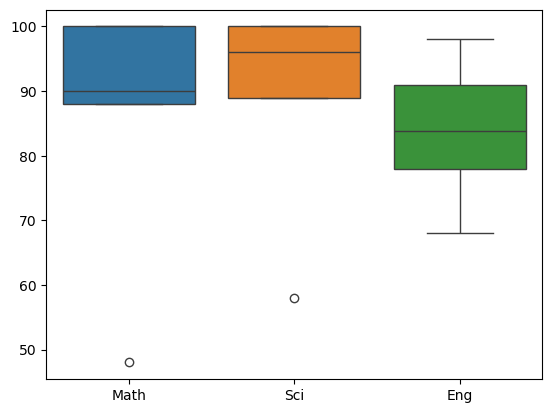

In [87]:
#outliers
sns.boxplot(data=df[['Math', 'Sci', 'Eng']])
plt.show()

In [88]:
#iqr method
Q1= df['Math'].quantile(0.25)
Q3= df['Math'].quantile(0.75)
IQR= Q3-Q1
lower= Q1 - 1.5*IQR
upper= Q3 + 1.5*IQR

outlier=df[(df['Math']<lower) | (df['Math']>upper)]
print(outlier)

  Name  Math   Sci   Eng
0    A  48.0  58.0  98.0


In [89]:
df['Math_zscore']= (df['Math']-df['Math'].mean())/df['Math'].std()

In [90]:
df['Math_norm']=(df['Math']-df['Math'].min())/(df['Math'].max()-df['Math'].min())

In [91]:
df

,Name,Math,Sci,Eng,Math_zscore,Math_norm
0,A,48.0,58.0,98.00,-1.728457,0.000000
1,B,88.0,89.0,78.00,0.130099,0.769231
2,C,100.0,100.0,83.75,0.687666,1.000000
3,D,90.0,96.0,91.00,0.223027,0.807692
4,E,100.0,100.0,68.00,0.687666,1.000000
